In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from ASM_utils import AdaptiveSmoothing
from matplotlib.colors import LinearSegmentedColormap
import warnings 
import os
import random
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino']
warnings.filterwarnings("ignore")
device = torch.device("cpu")
lane = 1
rds = np.load(f'../data/processed_data/rds/lane{lane}/2024-07-09.npy')
speed = np.load(f'../data/processed_data/rds/lane{lane}/2024-07-09.npy')
motion = np.load(f'../data/processed_data/motion/lane{lane}/2024-07-09.npy')
space_size, time_size = speed.shape
speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions

dx = 0.02                  # distance per cell
dt = 4.0                    # time per cell
kernel_time_window = time_size * dt  # seconds
kernel_space_window = space_size * dx  # same units as dx
MILE_TO_KM = 1.60934

Lane 1, 2024-07-08 - Wasserstein distance: 2.79, RMSE: 9.93


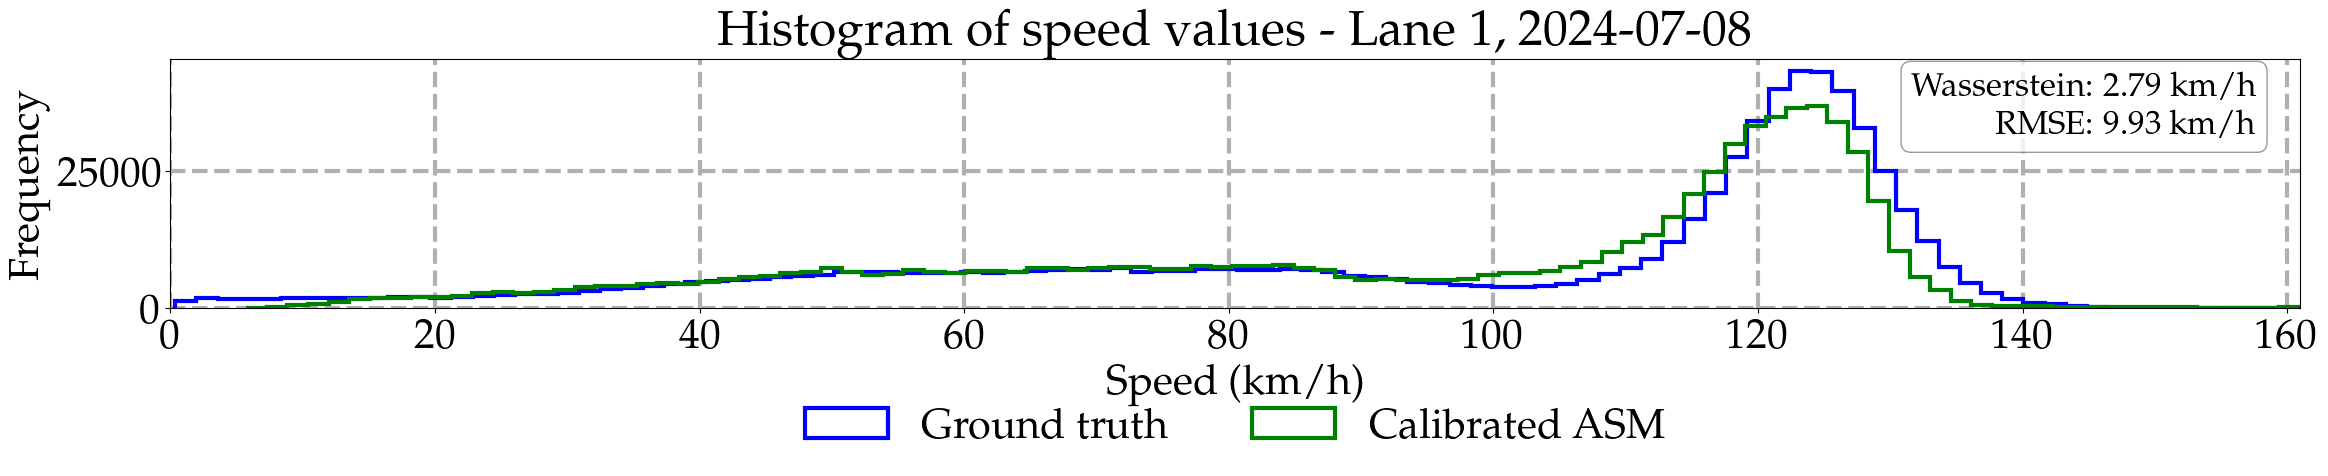

Lane 1, 2024-07-09 - Wasserstein distance: 3.47, RMSE: 11.40


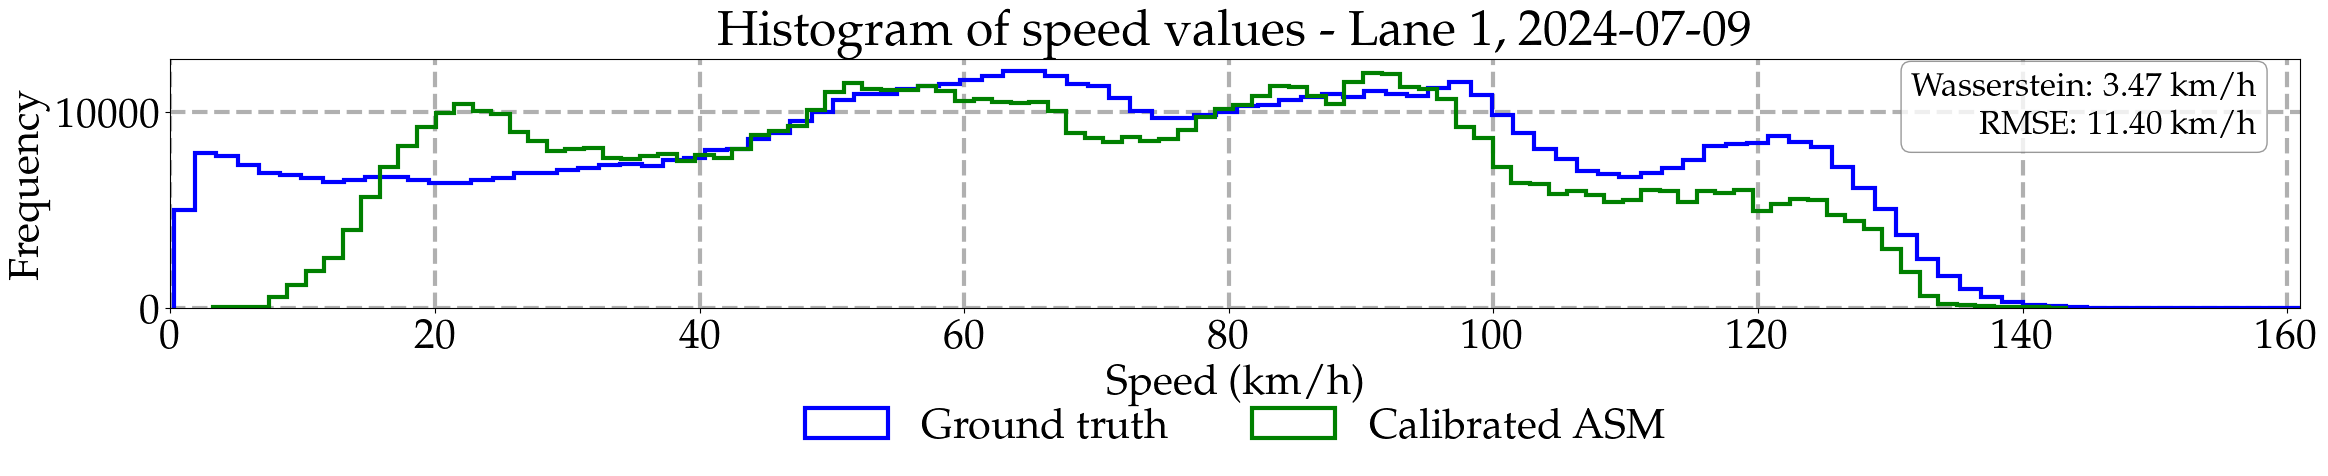

Lane 1, 2024-07-10 - Wasserstein distance: 3.07, RMSE: 10.99


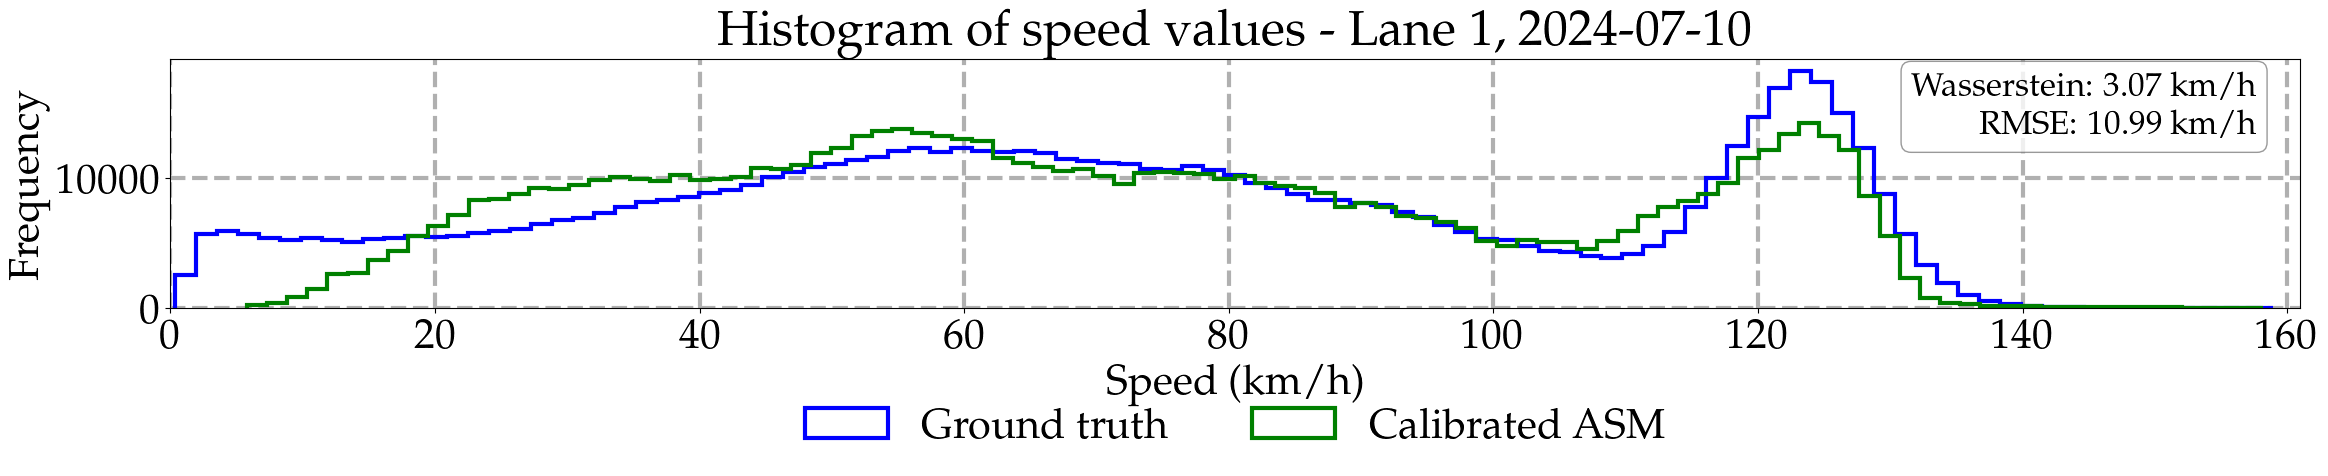

Lane 1, 2024-07-11 - Wasserstein distance: 3.19, RMSE: 12.26


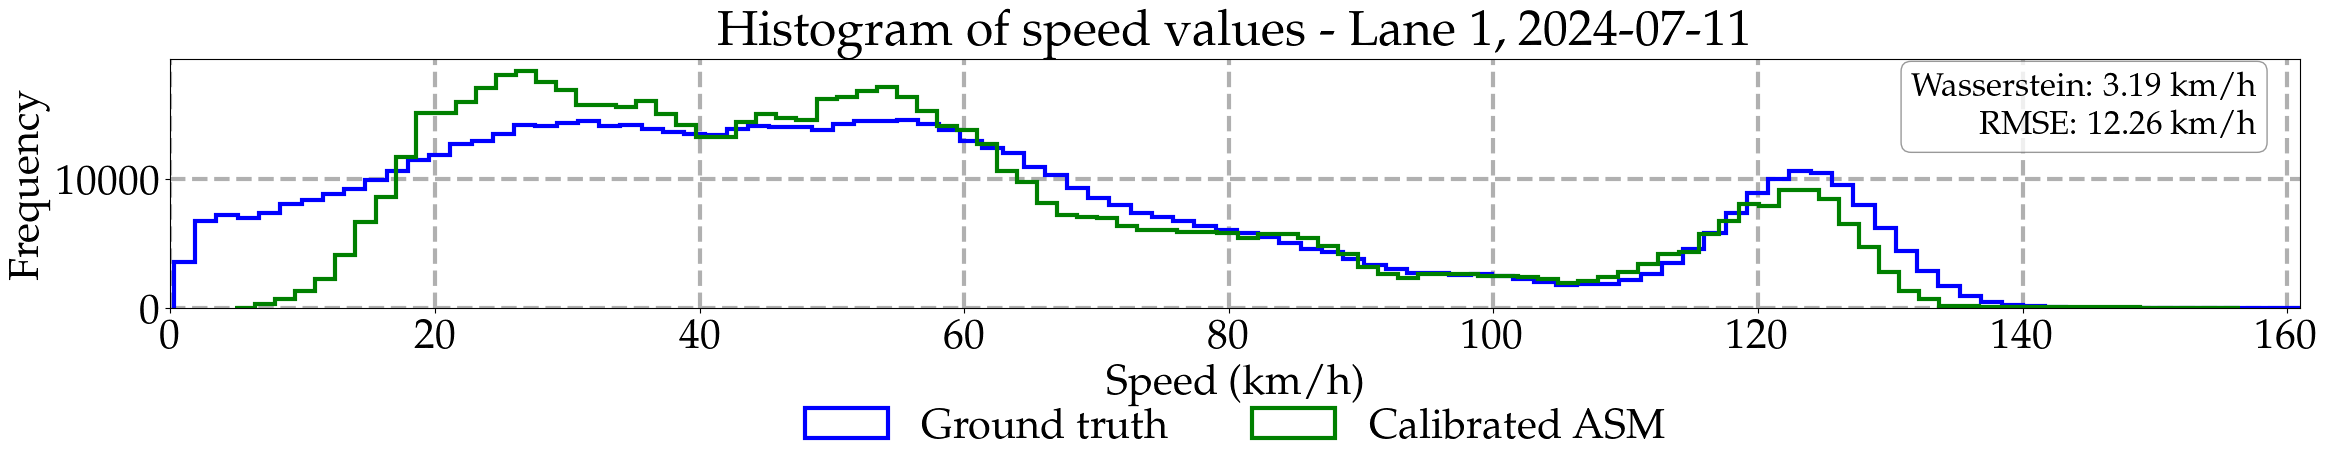

Lane 1, 2024-07-12 - Wasserstein distance: 4.20, RMSE: 12.53


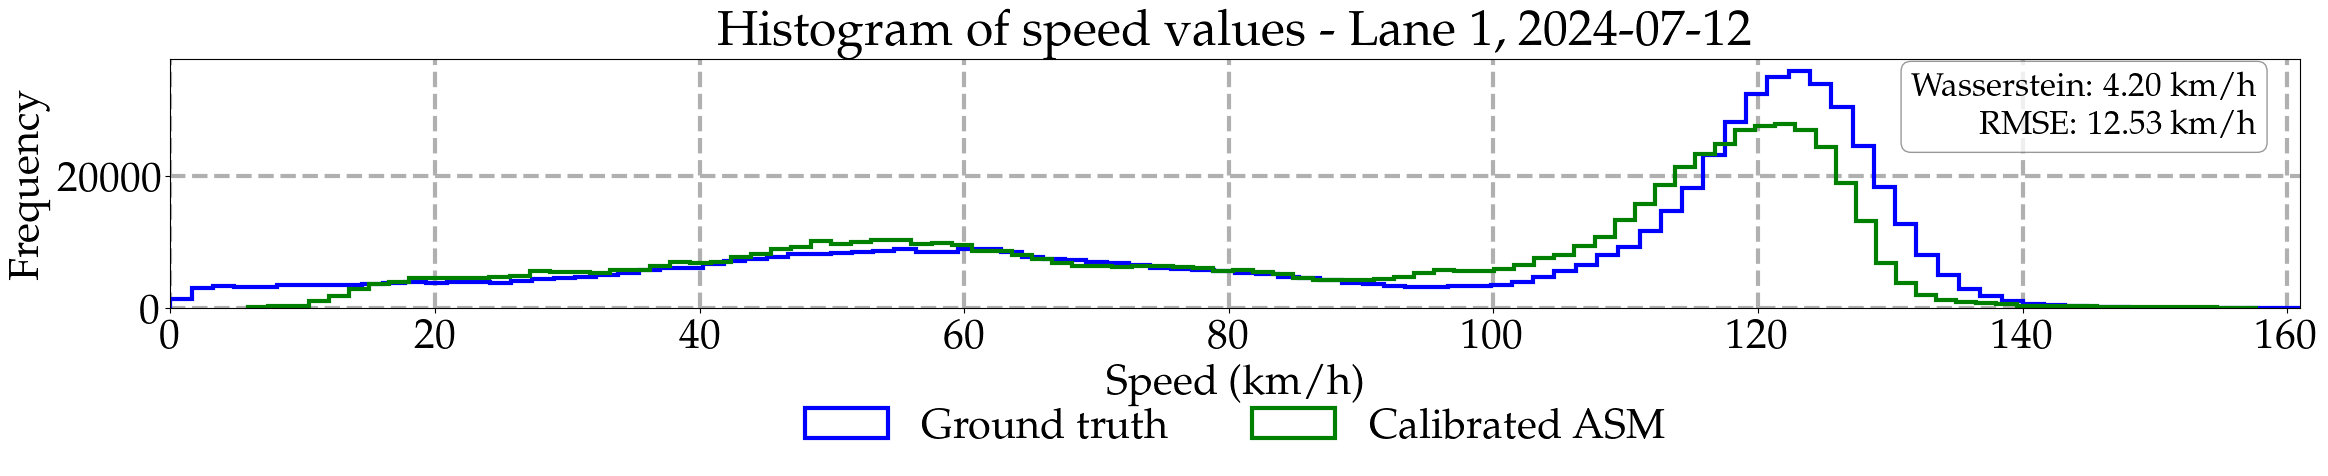

Lane 2, 2024-07-08 - Wasserstein distance: 1.28, RMSE: 8.50


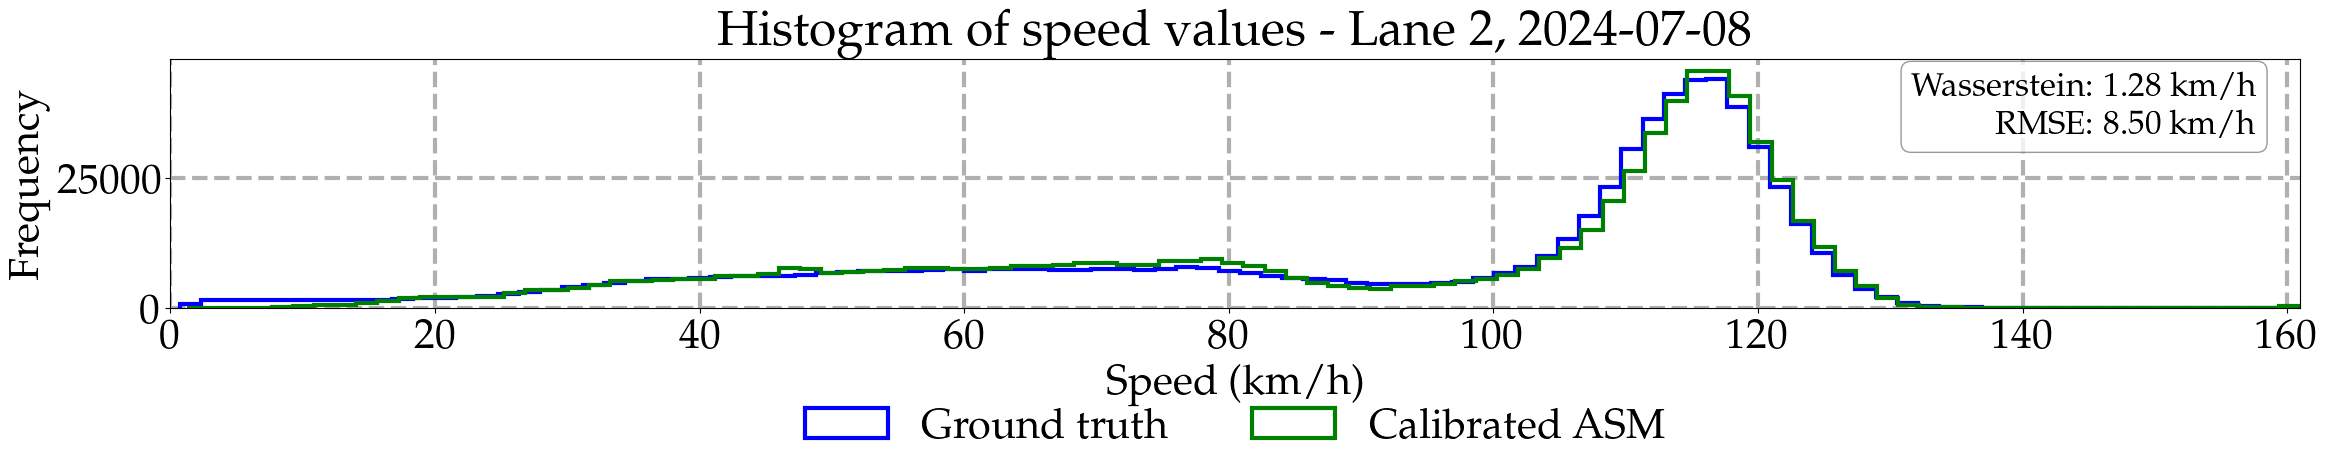

Lane 2, 2024-07-09 - Wasserstein distance: 2.41, RMSE: 9.91


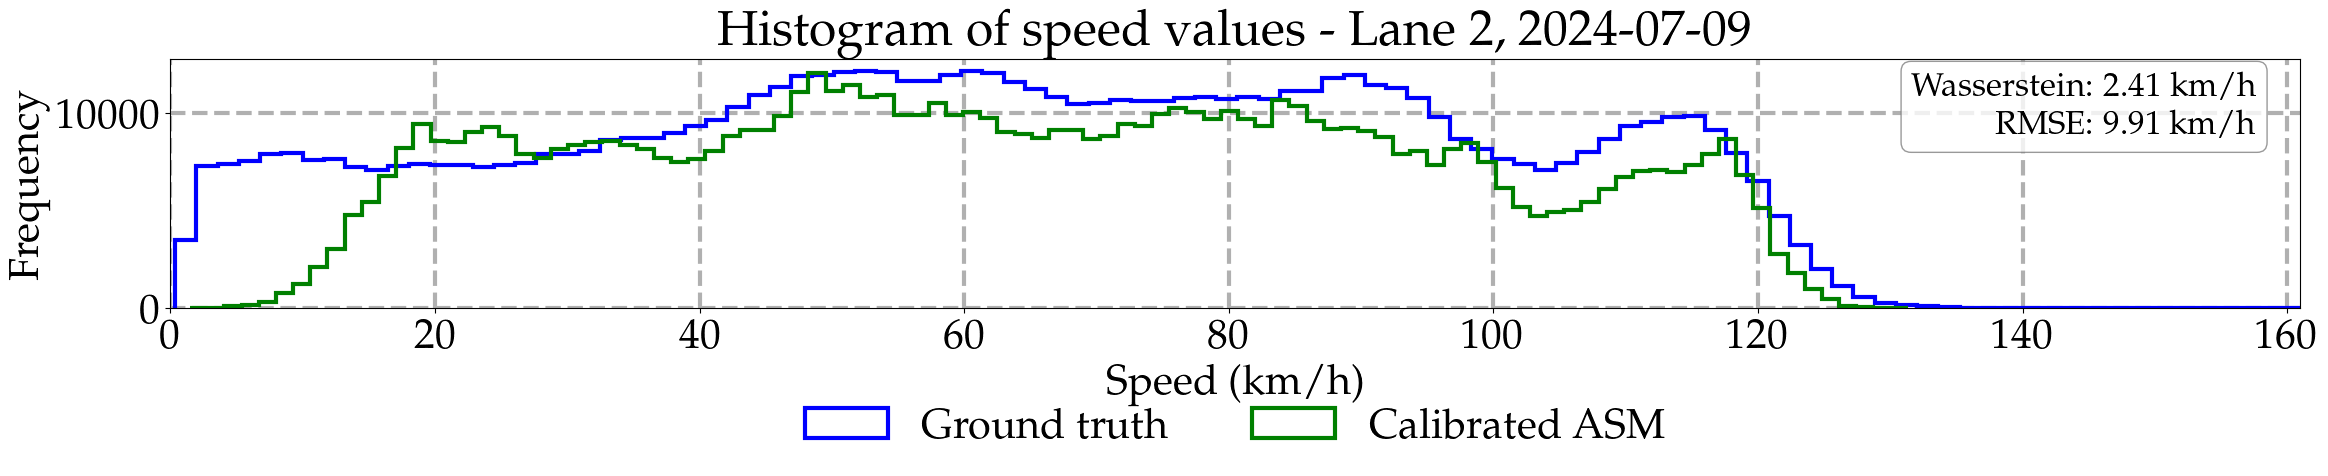

Lane 2, 2024-07-10 - Wasserstein distance: 2.14, RMSE: 9.34


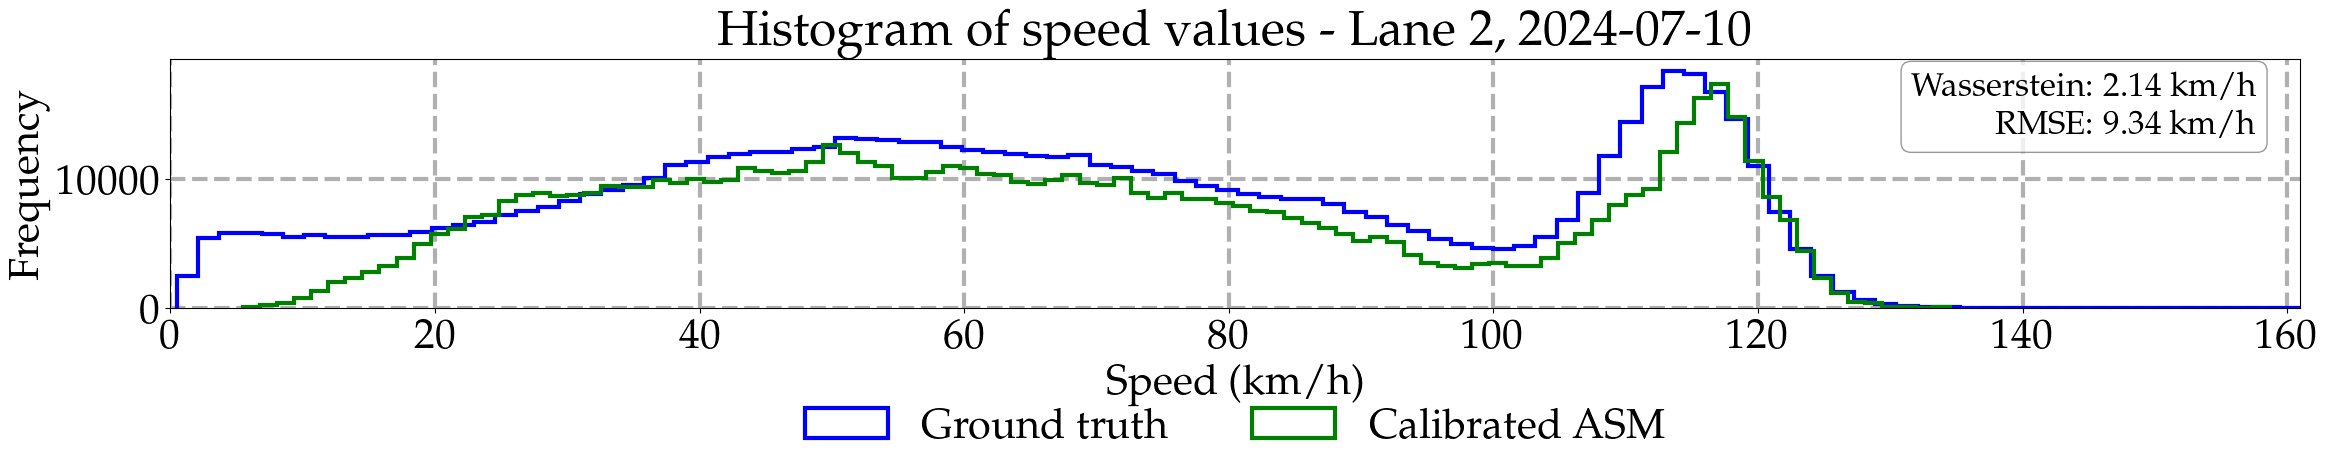

Lane 2, 2024-07-11 - Wasserstein distance: 2.81, RMSE: 10.40


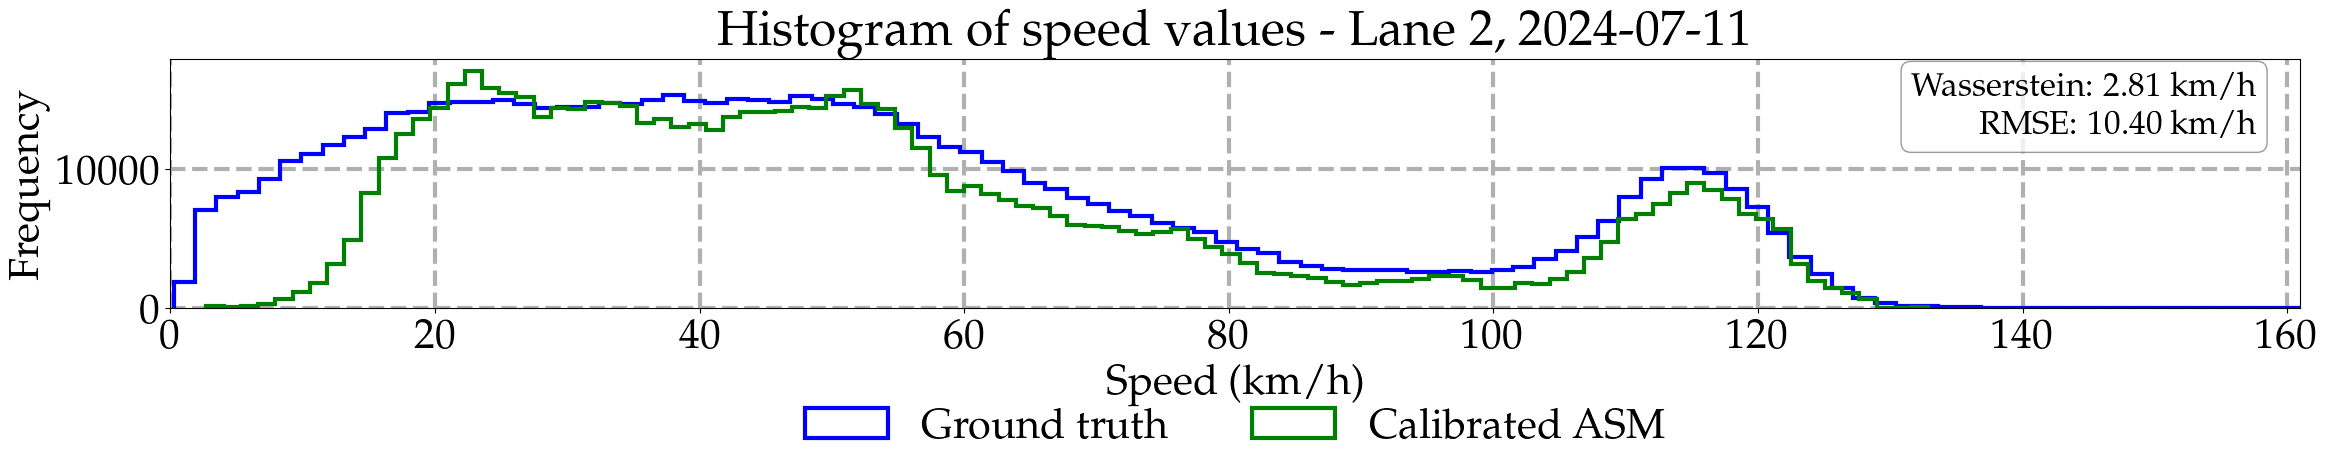

Lane 2, 2024-07-12 - Wasserstein distance: 1.83, RMSE: 10.28


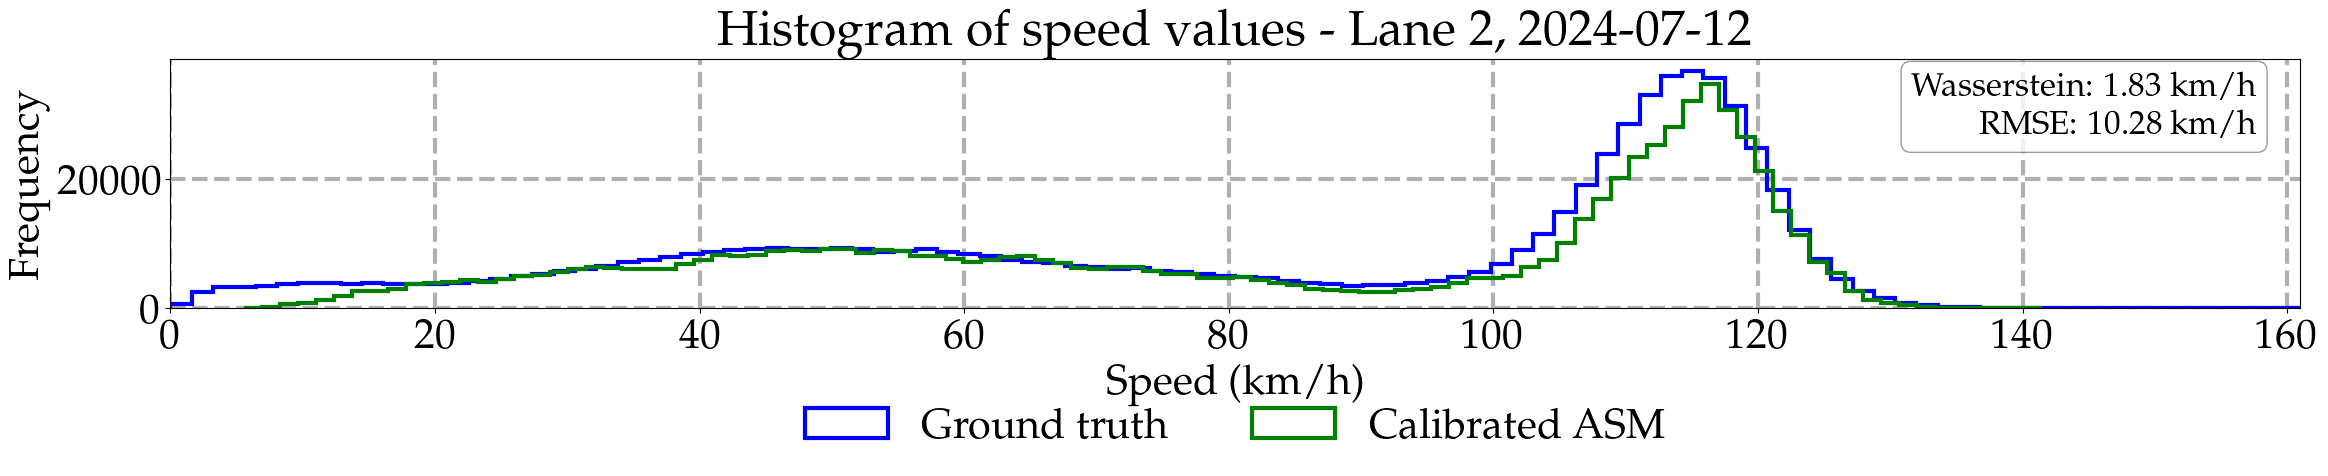

Lane 3, 2024-07-08 - Wasserstein distance: 1.55, RMSE: 8.23


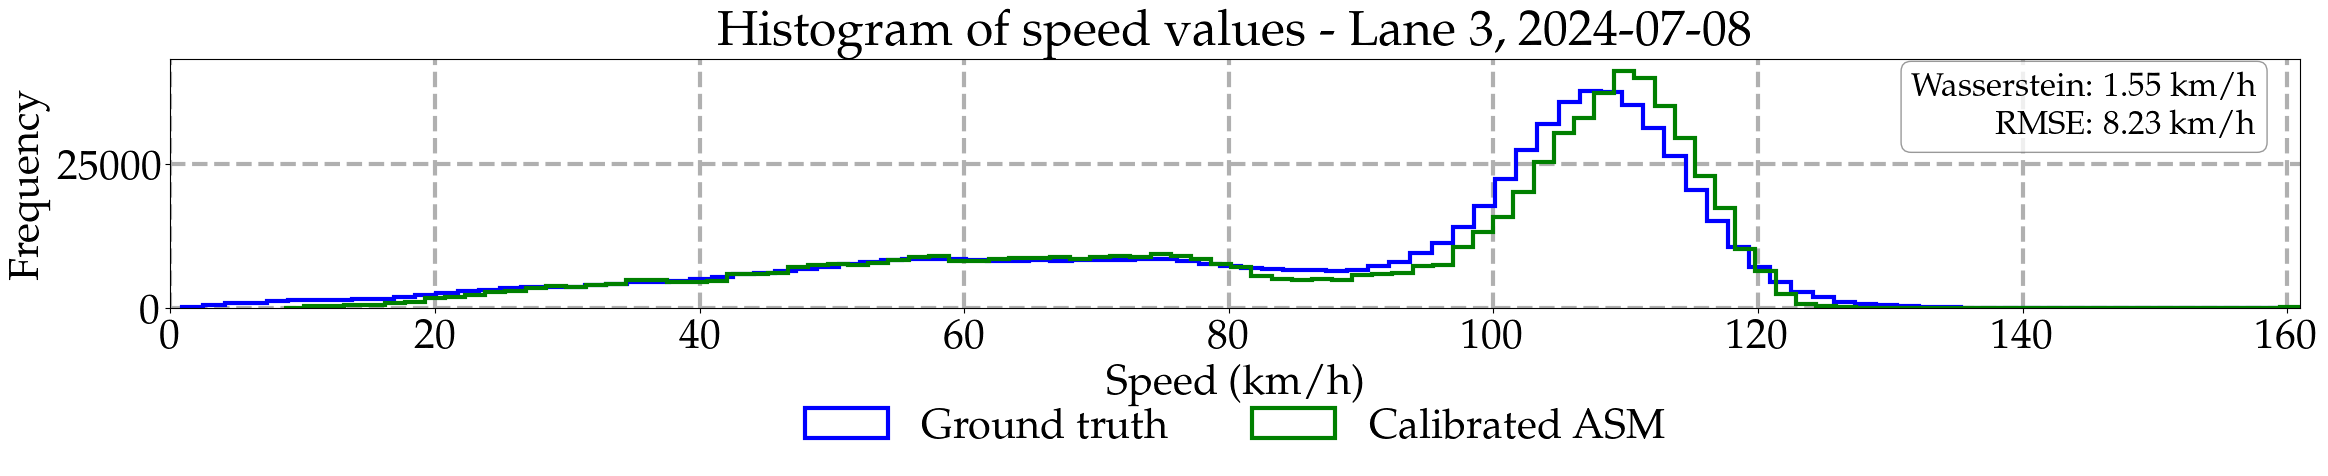

Lane 3, 2024-07-09 - Wasserstein distance: 2.04, RMSE: 9.46


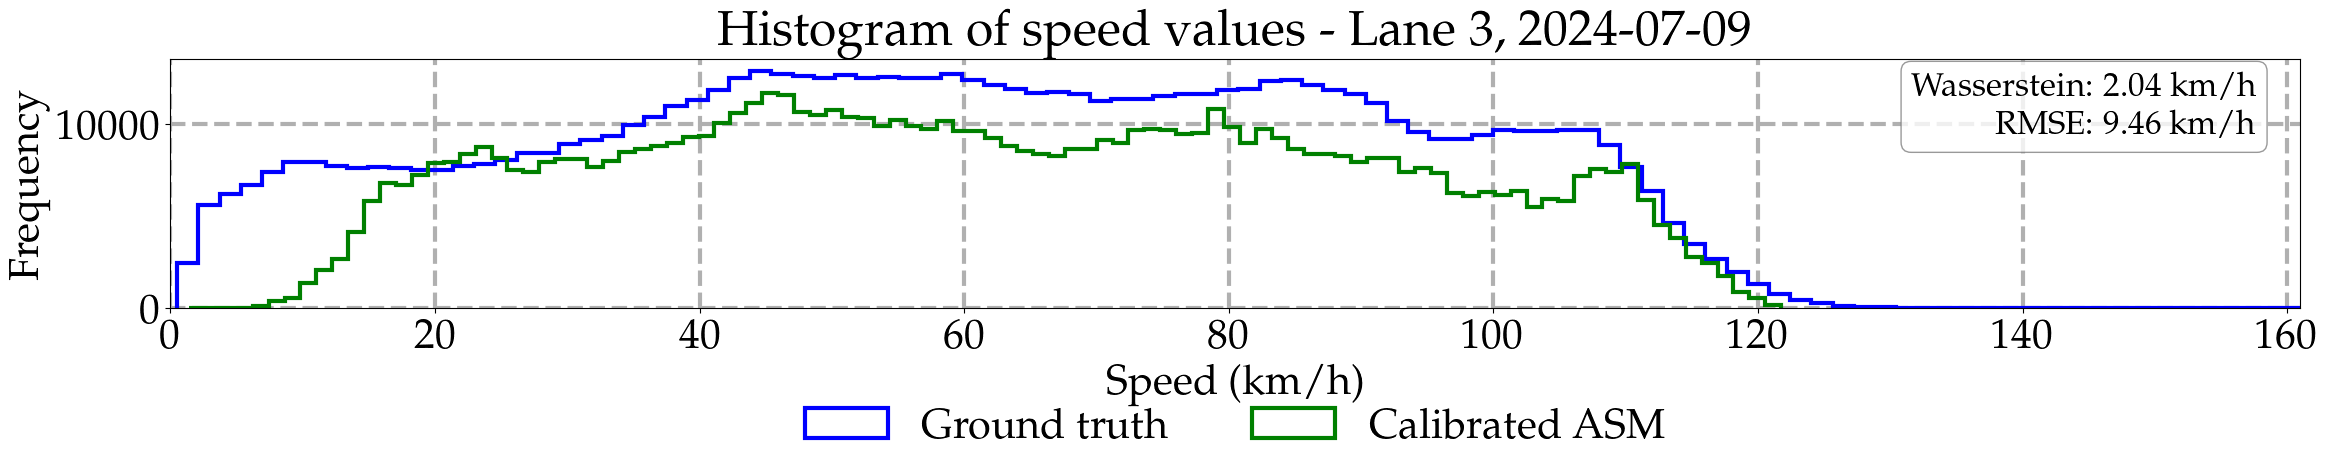

Lane 3, 2024-07-10 - Wasserstein distance: 1.75, RMSE: 8.68


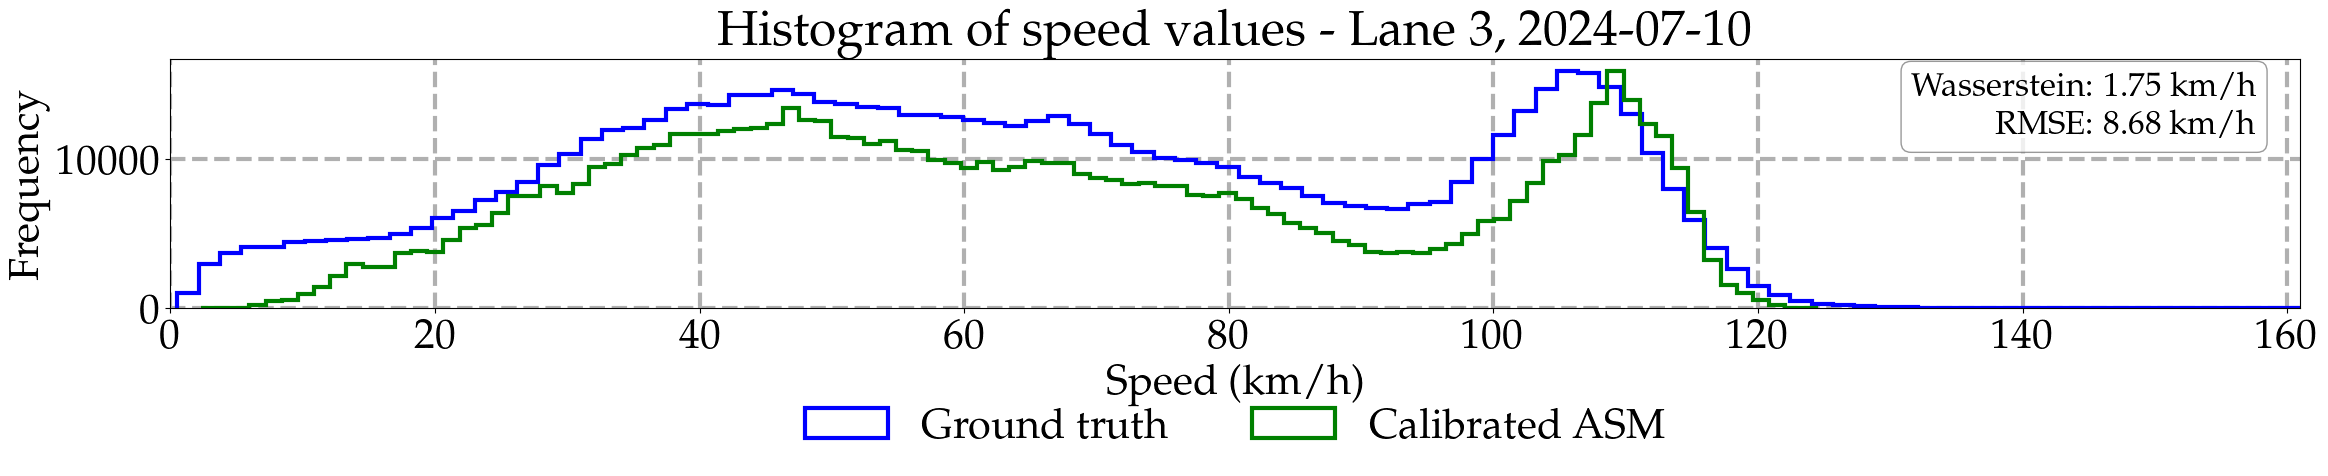

Lane 3, 2024-07-11 - Wasserstein distance: 2.67, RMSE: 9.60


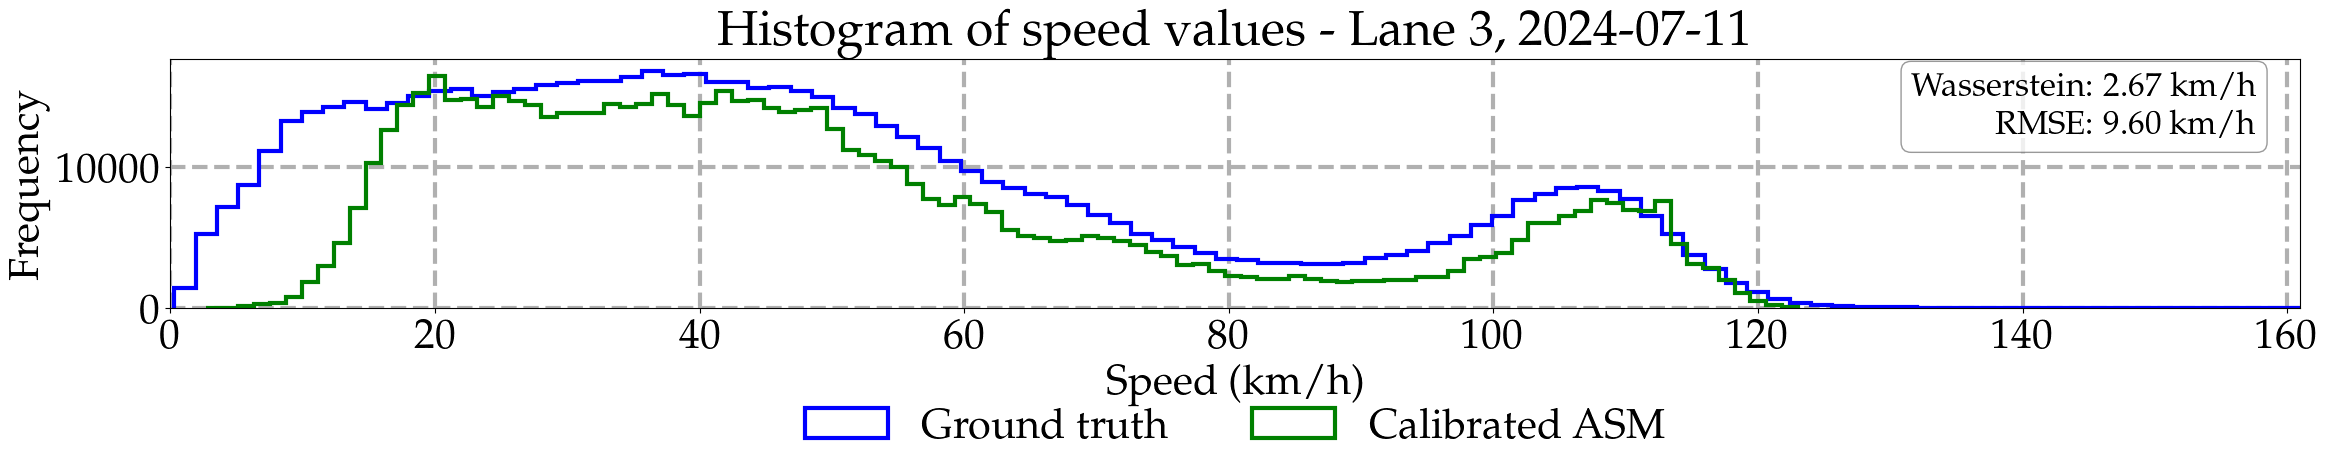

Lane 3, 2024-07-12 - Wasserstein distance: 1.91, RMSE: 9.91


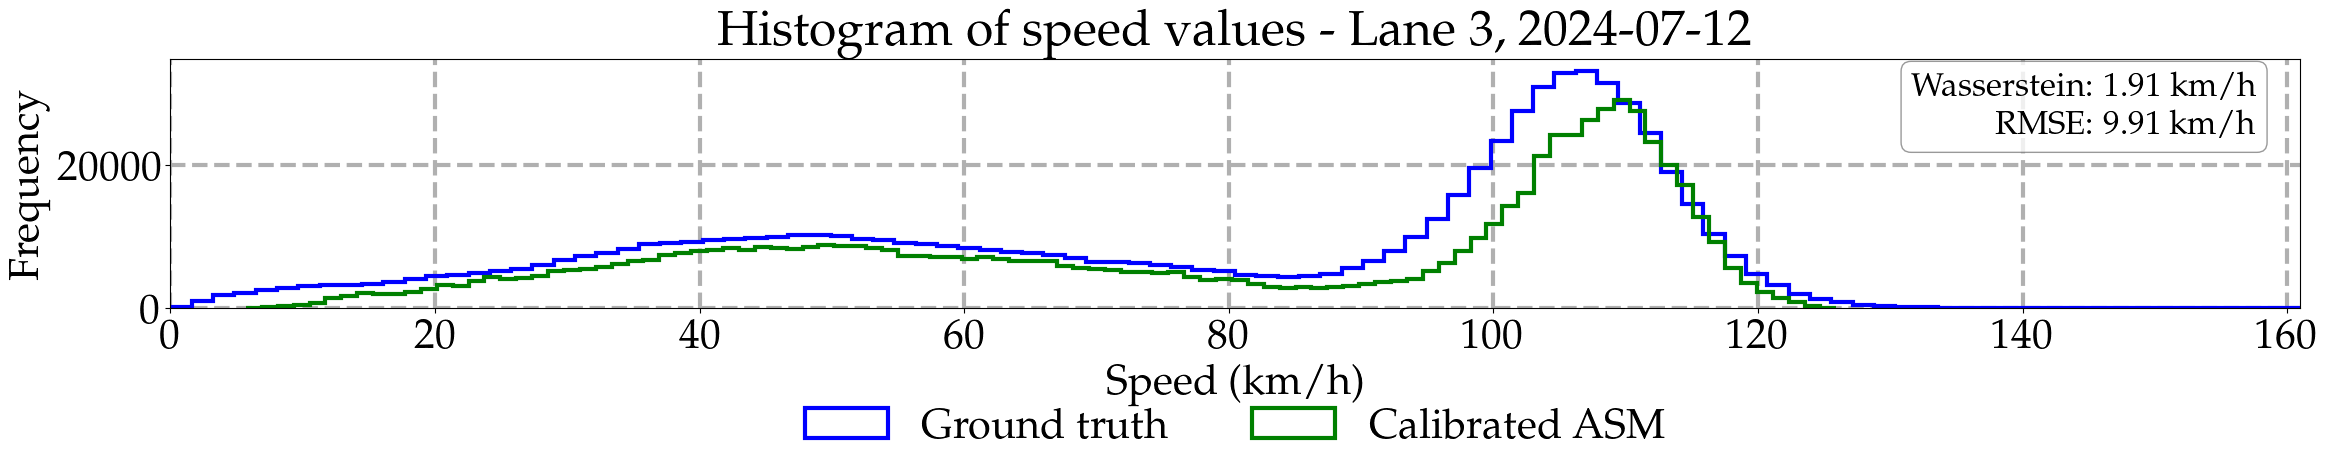

Lane 4, 2024-07-08 - Wasserstein distance: 1.79, RMSE: 9.25


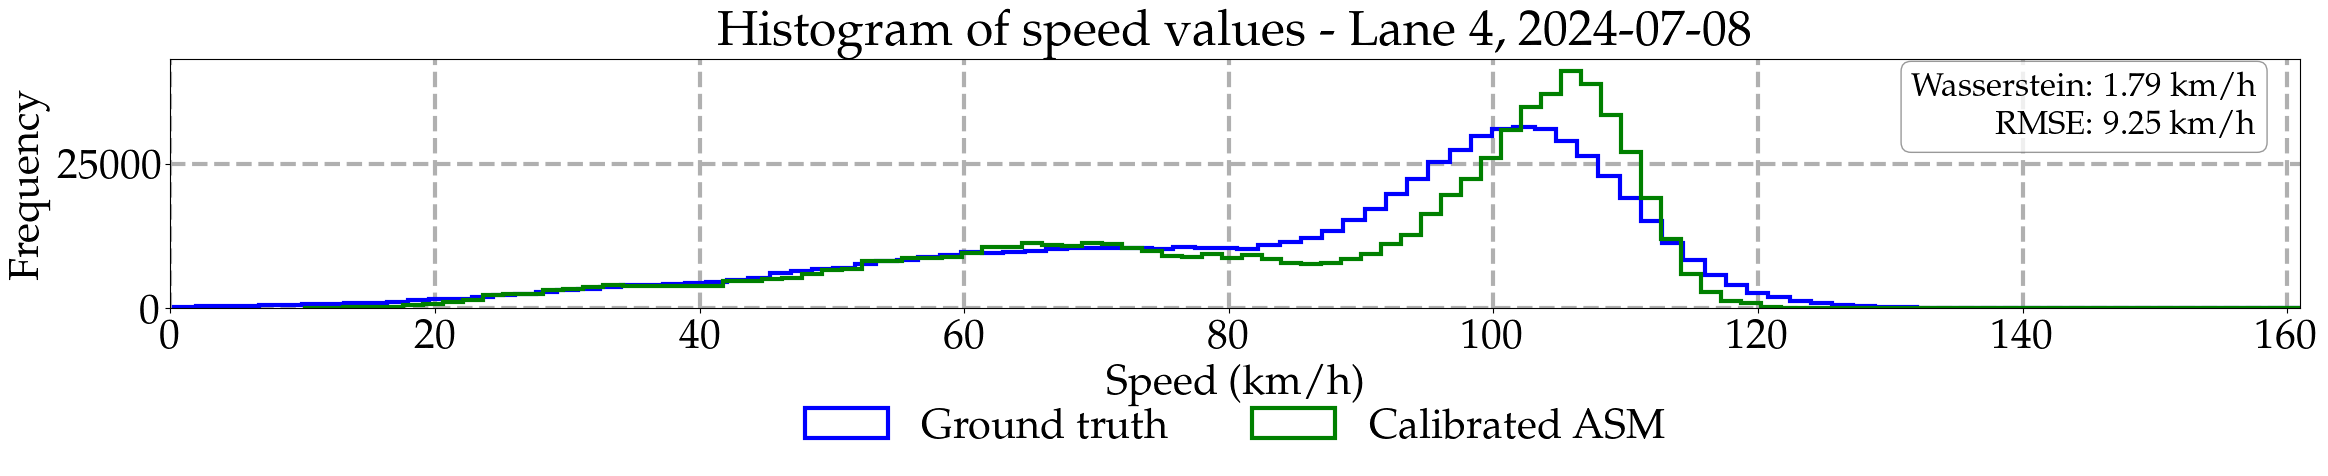

Lane 4, 2024-07-09 - Wasserstein distance: 1.94, RMSE: 10.39


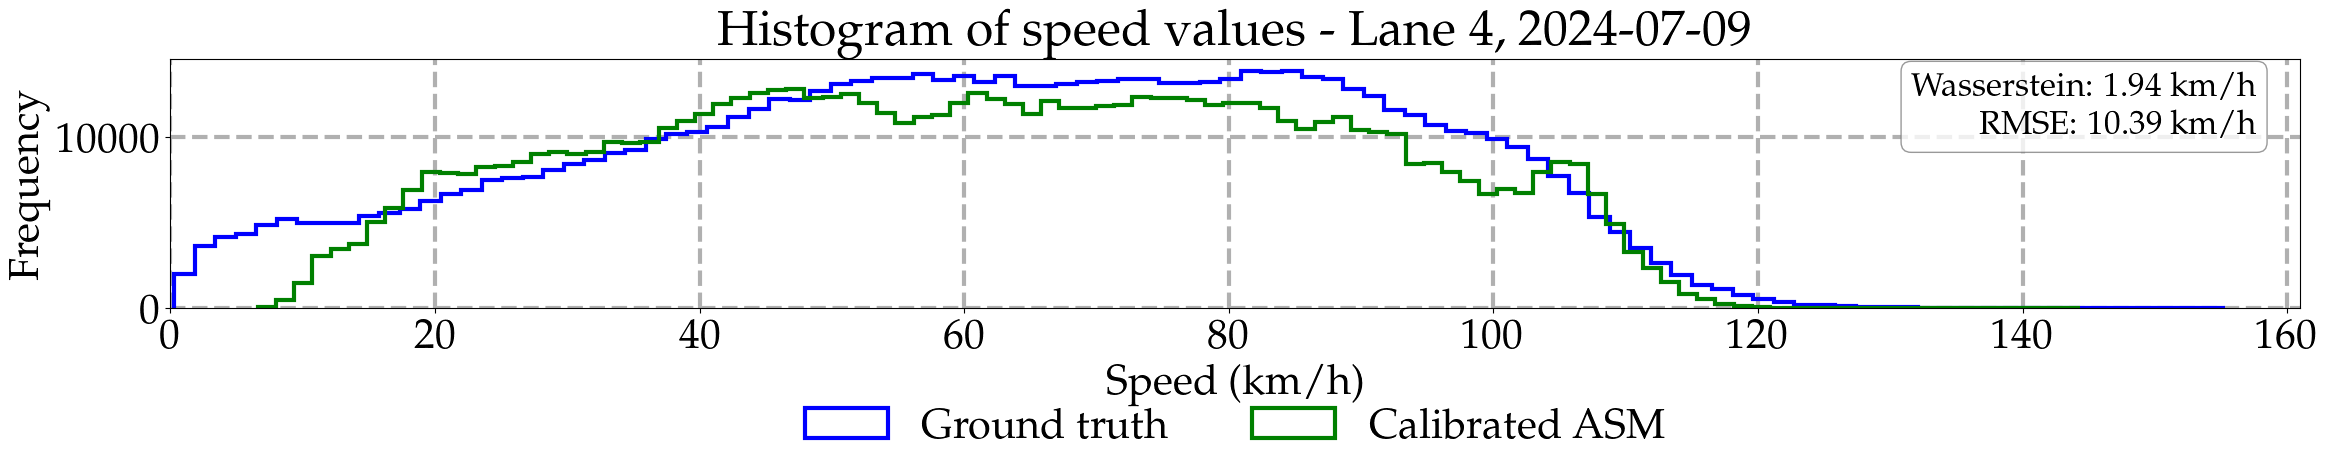

Lane 4, 2024-07-10 - Wasserstein distance: 1.88, RMSE: 10.02


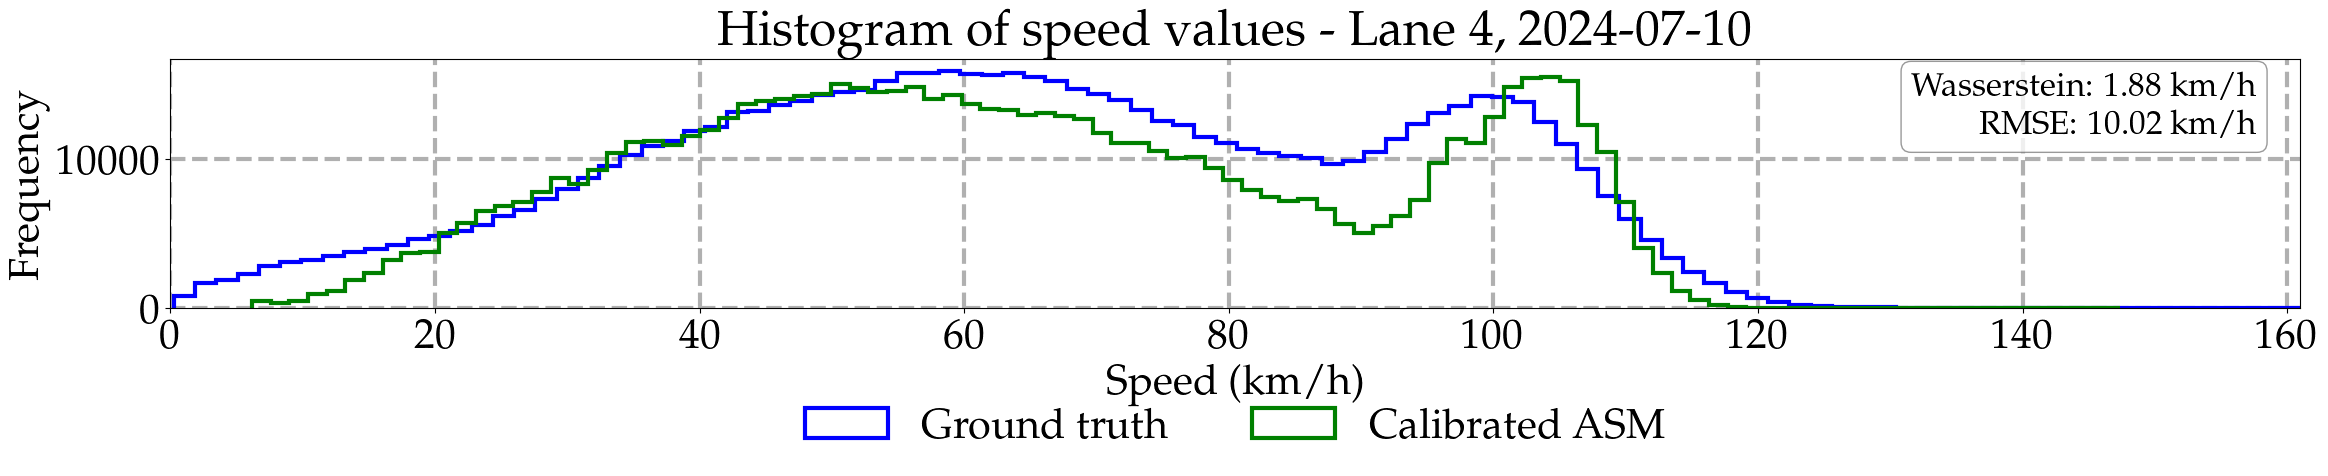

Lane 4, 2024-07-11 - Wasserstein distance: 2.77, RMSE: 10.95


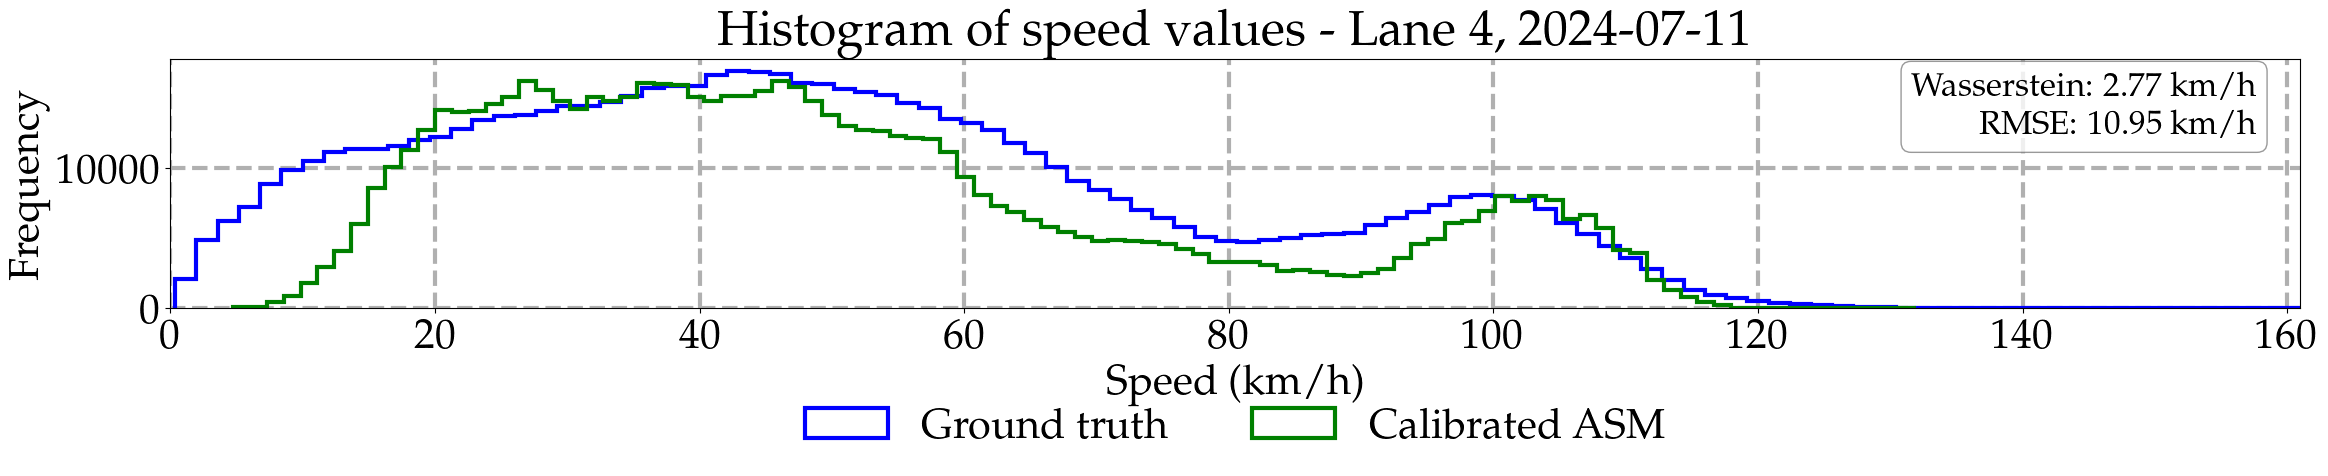

Lane 4, 2024-07-12 - Wasserstein distance: 1.88, RMSE: 10.73


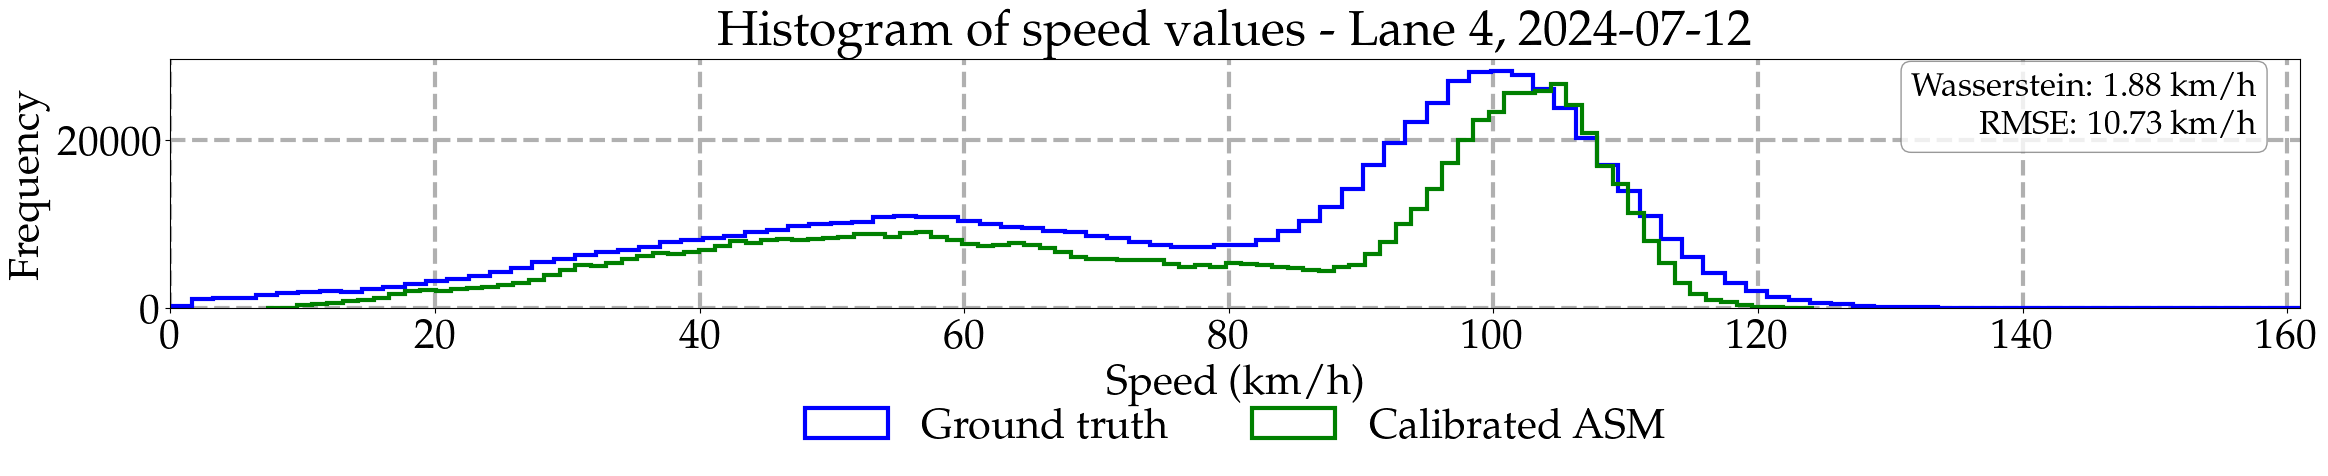


Results summary saved to '../figures/more-days/metrics_summary.csv'
 lane       date      RMSE  Wasserstein
    1 2024-07-08  9.932715     2.794402
    1 2024-07-09 11.403470     3.465607
    1 2024-07-10 10.989479     3.069438
    1 2024-07-11 12.255930     3.192197
    1 2024-07-12 12.531443     4.199140
    2 2024-07-08  8.497845     1.282192
    2 2024-07-09  9.914493     2.412205
    2 2024-07-10  9.342277     2.138416
    2 2024-07-11 10.396190     2.808589
    2 2024-07-12 10.278408     1.831444
    3 2024-07-08  8.226074     1.550318
    3 2024-07-09  9.460762     2.044253
    3 2024-07-10  8.681025     1.750469
    3 2024-07-11  9.599097     2.673122
    3 2024-07-12  9.914907     1.910487
    4 2024-07-08  9.253580     1.793950
    4 2024-07-09 10.389706     1.936116
    4 2024-07-10 10.020729     1.875033
    4 2024-07-11 10.949787     2.770715
    4 2024-07-12 10.728716     1.876990


In [26]:
results = []  # Store results for later plotting

for lane in [1,2,3,4]:
    for date in ['2024-07-08', '2024-07-09', '2024-07-10', '2024-07-11', '2024-07-12']:
        # load the best model
        best_model_path = f'../model/20250607_221107/best_model_lane{lane}.pt'
        calibrated_model = torch.load(best_model_path, map_location=device)
        calibrated = AdaptiveSmoothing(kernel_time_window,
                                kernel_space_window,
                                dx, dt,
                                init_tau=calibrated_model['tau'],
                                init_delta=calibrated_model['delta'],
                                init_c_cong=calibrated_model['c_cong'],
                                init_c_free=calibrated_model['c_free'],
                                init_v_delta=calibrated_model['v_delta'],
                                init_v_thr=calibrated_model['v_thr']
                                ).to(device)

        calibrated.eval()
        rds = np.load(f'../data/processed_data/rds/lane{lane}/{date}.npy')
        speed = np.load(f'../data/processed_data/rds/lane{lane}/{date}.npy')
        motion = np.load(f'../data/processed_data/motion/lane{lane}/{date}.npy')
        # how to make sure the speed falling into correct range 0 to 100 mph
        speed = np.clip(speed, 0, 100)
        rds = np.clip(rds, 0, 100)
        motion = np.clip(motion, 0, 100)
        space_size, time_size = speed.shape
        speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
        with torch.no_grad():
            smoothed = calibrated(speed)
            calibrated_asm_speed = smoothed.cpu().numpy().squeeze()
            calibrated_asm_speed = np.clip(calibrated_asm_speed, 0, 100)
        
        from scipy.stats import wasserstein_distance
        wd = wasserstein_distance(MILE_TO_KM * motion.flatten(), MILE_TO_KM * calibrated_asm_speed.flatten())
        rmse = np.sqrt(np.mean((MILE_TO_KM * motion.flatten() - MILE_TO_KM * calibrated_asm_speed.flatten())**2))
        
        # Save results to table
        results.append({'lane': lane, 'date': date, 'RMSE': rmse, 'Wasserstein': wd})
        
        plt.figure(figsize=(24, 6))
        plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
        plt.hist(MILE_TO_KM * motion.flatten(), bins=100, histtype='step', color='blue', label='Ground truth', linewidth=3)
        plt.hist(MILE_TO_KM * calibrated_asm_speed.flatten(), bins=100, histtype='step', color='green', label='Calibrated ASM', linewidth=3)
        plt.xlabel('Speed (km/h)')
        plt.ylabel('Frequency')
        plt.title(f'Histogram of speed values - Lane {lane}, {date}')
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)
        plt.xlim(0, MILE_TO_KM * 100)
        plt.grid(lw=3, ls='--')
        
        # Add metrics text box in upper right corner
        textstr = f'Wasserstein: {wd:.2f} km/h\nRMSE: {rmse:.2f} km/h'
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        plt.gca().text(0.98, 0.95, textstr, transform=plt.gca().transAxes, fontsize=24,
                       verticalalignment='top', horizontalalignment='right', bbox=props)
        
        plt.tight_layout()
        print(f'Lane {lane}, {date} - Wasserstein distance: {wd:.2f}, RMSE: {rmse:.2f}')
        
        if not os.path.exists('../figures/more-days'):
            os.makedirs('../figures/more-days')
        plt.savefig(f'../figures/more-days/histogram_lane{lane}_{date}.pdf', dpi=300, bbox_inches='tight')
        plt.show()

# Create and save results table
results_df = pd.DataFrame(results)
results_df.to_csv('../figures/more-days/metrics_summary.csv', index=False)
print("\nResults summary saved to '../figures/more-days/metrics_summary.csv'")
print(results_df.to_string(index=False))

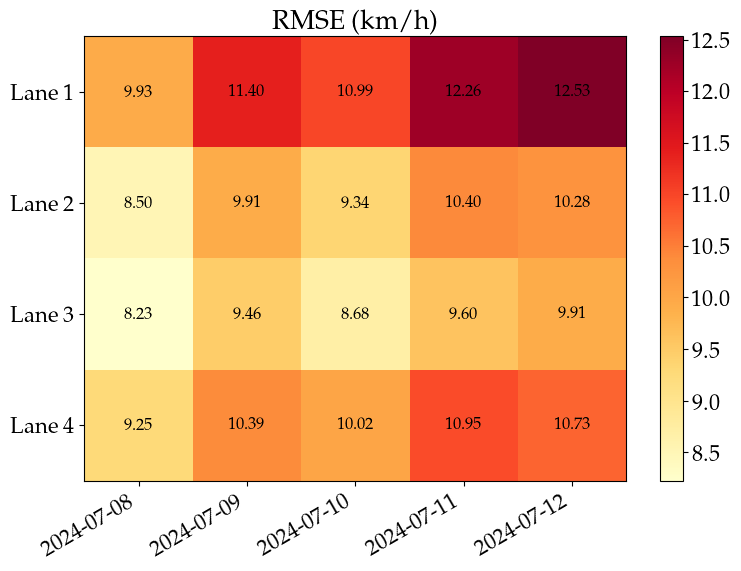

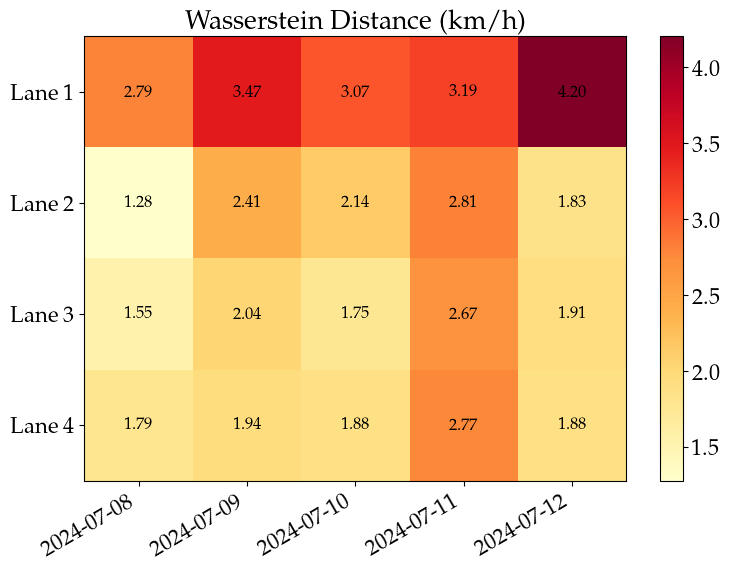

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv('../figures/more-days/metrics_summary.csv')

plt.rcParams.update({'font.size': 16, 'font.family': 'serif'})

# Pivot for heatmap visualization
rmse_pivot = results_df.pivot(index='lane', columns='date', values='RMSE')
wd_pivot   = results_df.pivot(index='lane', columns='date', values='Wasserstein')

# -----------------------
# RMSE heatmap (Figure 1)
# -----------------------
fig1, ax1 = plt.subplots(figsize=(8, 6))

im1 = ax1.imshow(rmse_pivot.values, cmap='YlOrRd', aspect='auto')
ax1.set_xticks(range(len(rmse_pivot.columns)))
ax1.set_xticklabels(rmse_pivot.columns, rotation=30, ha='right')
ax1.set_yticks(range(len(rmse_pivot.index)))
ax1.set_yticklabels([f'Lane {i}' for i in rmse_pivot.index])
ax1.set_title('RMSE (km/h)')

cbar1 = plt.colorbar(im1, ax=ax1)

# Text annotations
for i in range(len(rmse_pivot.index)):
    for j in range(len(rmse_pivot.columns)):
        ax1.text(j, i, f'{rmse_pivot.values[i, j]:.2f}',
                 ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.savefig('../figures/more-days/rmse_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()


# --------------------------------
# Wasserstein heatmap (Figure 2)
# --------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 6))

im2 = ax2.imshow(wd_pivot.values, cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(len(wd_pivot.columns)))
ax2.set_xticklabels(wd_pivot.columns, rotation=30, ha='right')
ax2.set_yticks(range(len(wd_pivot.index)))
ax2.set_yticklabels([f'Lane {i}' for i in wd_pivot.index])
ax2.set_title('Wasserstein Distance (km/h)')

cbar2 = plt.colorbar(im2, ax=ax2)

# Text annotations
for i in range(len(wd_pivot.index)):
    for j in range(len(wd_pivot.columns)):
        ax2.text(j, i, f'{wd_pivot.values[i, j]:.2f}',
                 ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.savefig('../figures/more-days/wasserstein_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()
